In [1]:
import os
# Setează numărul de nuclee dorit (ex: 16)
n_core = "16"
os.environ["OMP_NUM_THREADS"] = n_core
os.environ["MKL_NUM_THREADS"] = n_core
os.environ["OPENBLAS_NUM_THREADS"] = n_core
os.environ["VECLIB_MAXIMUM_THREADS"] = n_core
os.environ["NUMEXPR_NUM_THREADS"] = n_core

import numpy as np
import warnings
# suppress warnings
warnings.filterwarnings('ignore')



import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Documentație Matematică: Detecția Anomaliilor prin Modelul Gaussian

Modelul se bazează pe **Estimarea Densității de Probabilitate** ($p(x)$). Presupunem că datele normale urmează o distribuție Gaussiană (Normală). Dacă un punct nou are o probabilitate $p(x)$ mai mică decât un prag critic $\epsilon$, acesta este clasificat ca anomalie.

---

### 1. Faza de Antrenare: Estimarea Parametrilor

Pentru fiecare caracteristică (feature) $j$ din setul de date (unde $j = 1, 2, \dots, n$), modelul trebuie să învețe geometria datelor normale calculând doi parametri statistici:

#### A. Media ($\mu_j$)
Reprezintă centrul de masă al valorilor normale pentru caracteristica $j$.
$$\mu_j = \frac{1}{m} \sum_{i=1}^{m} x_j^{(i)}$$

#### B. Varianța ($\sigma_j^2$)
Măsoară gradul de împrăștiere a datelor în jurul mediei pentru caracteristica $j$.
$$\sigma_j^2 = \frac{1}{m} \sum_{i=1}^{m} (x_j^{(i)} - \mu_j)^2$$

*Unde:*
* $m$ = numărul total de exemple de antrenare.
* $x_j^{(i)}$ = valoarea caracteristicii $j$ pentru exemplul $i$.

---

### 2. Calculul Densității de Probabilitate $p(x)$

Presupunând că cele $n$ caracteristici sunt independente, probabilitatea totală ca un exemplu $x$ să aparțină distribuției normale este **produsul ($\prod$)** probabilităților fiecărei caracteristici în parte (folosind funcția de densitate Gaussiană Univariată):

$$p(x) = \prod_{j=1}^{n} p(x_j; \mu_j, \sigma_j^2) = \prod_{j=1}^{n} \frac{1}{\sqrt{2\pi\sigma_j^2}} \exp\left( -\frac{(x_j - \mu_j)^2}{2\sigma_j^2} \right)$$

În cod, această operație este vectorizată pentru eficiență:
1. `part1` $= \frac{1}{\sqrt{2\pi\sigma_j^2}}$
2. `part2` $= e^{-\frac{(x_j - \mu_j)^2}{2\sigma_j^2}}$
3. `np.prod(..., axis=1)` realizează produsul simbolic $\prod$ pe linii.

---

### 3. Faza de Validare: Optimizarea lui $\epsilon$ prin Maximizarea $F_1\text{-Score}$

Pragul critic $\epsilon$ (Epsilon) determină limita dintre normalitate și anomalie. Pentru a nu-l alege la întâmplare, testăm un interval liniar de valori potențiale și o selectăm pe cea care maximizează metrica $F_1\text{-Score}$.

#### Matricea de Confuzie (Elemente de bază)
* **True Positives ($TP$):** Exemplele care sunt real anomalii și au fost prezise corect ca anomalii ($p(x) < \epsilon$).
* **False Positives ($FP$):** Alarme false (date normale marcate eronat ca anomalii).
* **False Negatives ($FN$):** Alarme ratate (anomalii pe care modelul le-a considerat normale).

#### Precizia (Precision)
Măsoară calitatea alertelor declanșate (ce procent din alerte sunt corecte).
$$\text{Precision} = \frac{TP}{TP + FP}$$

#### Sensibilitatea (Recall)
Măsoară capacitatea modelului de a prinde anomaliile (ce procent din totalul anomaliilor reale a fost detectat).
$$\text{Recall} = \frac{TP}{TP + FN}$$

#### Scorul F1 ($F_1\text{-Score}$)
Este media armonică dintre Precizie și Sensibilitate. Oferă o măsură robustă a performanței pe seturi de date extrem de dezechilibrate.
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Modelul salvează acea valoare $\epsilon$ care oferă valoarea maximă pentru $F_1$.

---

### 4. Regula de Decizie Finală (Faza de Predicție)

Pentru orice vector nou de date $X_{\text{new}}$, funcția de predicție aplică următoarea axiomă matematică:

$$y_{\text{pred}} = \begin{cases} 1 & \text{dacă } p(X_{\text{new}}) < \epsilon \quad \Longrightarrow \text{\textbf{Anomalie}} \\ 0 & \text{dacă } p(X_{\text{new}}) \geq \epsilon \quad \Longrightarrow \text{\textbf{Normal}} \end{cases}$$


In [2]:


class GaussianAnomalyDetection:
    def __init__(self):
 
        self.epsilon = None    # Pragul critic (Epsilon) - determinat în faza de validare
        self.mu = None         # Vectorul cu mediile fiecărei caracteristici (features)
        self.sigma_sq = None   # Vectorul cu varianțele fiecărei caracteristici (σ²)

    # Modelul învață cum arată normalitatea
    # X trebuie să conțină DOAR exemple normale !!!
    # X: Matrice NumPy de formă (m_exemple, n_caracteristici)
    def fit(self, X):
        
        # np.mean(..., axis=0) calculează media pe verticală, pentru fiecare coloană în parte
        # Rezultatul este un vector de lungime 'n_caracteristici'
        self.mu = np.mean(X, axis=0)
        
        # np.var(..., axis=0) calculează varianța (împrăștierea) pentru fiecare coloană
        # σ² = (1/m) * Σ(x - μ)²
        self.sigma_sq = np.var(X, axis=0)
        
        # Dacă o caracteristică are varianță 0 (toate valorile sunt identice),
        # Înlocuim 0 cu o valoare minusculă (1e-9).
        self.sigma_sq[self.sigma_sq == 0] = 1e-9


    # Calculează densitatea de probabilitate p(x) pentru fiecare rând.
    # Folosește formula Distribuției Gaussiene Univariate pentru fiecare coloană,
    # apoi le înmulțește pentru a obține probabilitatea totală a exemplului.
    def _compute_probability(self, X):

        # Partea statică a formulei Gaussiene: 1 / sqrt(2 * pi * σ²)
        part1 = 1 / np.sqrt(2 * np.pi * self.sigma_sq)
        
        # Partea exponențială a formulei: e^( -(x - μ)² / (2 * σ²) )
        part2 = np.exp(-((X - self.mu) ** 2) / (2 * self.sigma_sq))
        
        # Combinăm cele două părți. NumPy face operația element cu element (vectorizat).
        # 'p_features' este o matrice de aceeași formă cu X, 
        # conținând probabilitatea per caracteristică.
        p_features = part1 * part2
        
        # Probabilitatea totală a unui rând este PRODUSUL probabilităților
        # caracteristicilor sale (Π p(x_j))
        # np.prod(..., axis=1) înmulțește valorile pe orizontală, 
        # generând un vector de lungime 'm_exemple'
        p_total = np.prod(p_features, axis=1)
        
        return p_total


    # Găsește valoarea optimă pentru Epsilon 
    # Se folosește un set de date mixt (date normale + anomalii) unde cunoaștem etichetele reale.
    # Parametri:
    # X_val: Matricea de caracteristici pentru validare.
    # y_val: Vectorul cu etichete reale (0 = Normal, 1 = Anomalie)
    def select_threshold(self, X_val, y_val):

        # Pasul 1: Calculăm probabilitățile brute pentru toate exemplele din setul de validare
        p_val = self._compute_probability(X_val)
        
        # Inițializăm variabilele în care vom salva cel mai bun rezultat descoperit
        best_epsilon = 0
        best_f1 = -1
        
        # Pasul 2: Împărțim intervalul dintre cea mai mică și cea mai mare 
        # probabilitate în 1000 de pași.
        # Astfel, testăm 1000 de valori potențiale pentru Epsilon.
        min_p = np.min(p_val)
        max_p = np.max(p_val)
        step_size = (max_p - min_p) / 1000
        
        # Pasul 3: Rulăm bucla de căutare (Grid Search liniar)
        for epsilon in np.arange(min_p, max_p, step_size):
            
            # PREDICȚIE TEMPORARĂ: Dacă probabilitatea < epsilon, 
            # este anomalie (1), altfel normal (0)
            # .astype(int) transformă valorile booleene [True, False] în [1, 0]
            predictions = (p_val < epsilon).astype(int)
            
            # MATRICEA DE CONFUZIE (Calculată prin măști booleene ):
            
            # True Positives (TP): Modelul a prezis corect că este Anomalie (1 și 1)
            tp = np.sum((predictions == 1) & (y_val == 1))
            
            # False Positives (FP): Alarme false. 
            # Modelul a prezis că e Anomalie, dar era Normal (1 și 0)
            fp = np.sum((predictions == 1) & (y_val == 0))
            
            # False Negatives (FN): Alarme ratate. 
            # Modelul a prezis că e Normal, dar era Anomalie (0 și 1)
            fn = np.sum((predictions == 0) & (y_val == 1))

            
            # CALCULUL METRICELOR 
            
            # (Prevenim erorile de împărțire la zero cu structuri 'if')
            # Precizia: Din tot ce am marcat ca anomalie, cât a fost real?
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            
            # Recall (Sensibilitatea): Din toate anomaliile reale, câte am reușit să prindem?
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            
            # F1-Score: Media armonică dintre Precizie și Recall. 
            # Penalizează dezechilibrele extreme.
            f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            # DECIZIA: Dacă F1-Score-ul curent este mai mare decât cel mai bun scor de până acum,
            # salvăm acest Epsilon și acest scor ca fiind noile repere optime.
            if f1 > best_f1:
                best_f1 = f1
                best_epsilon = epsilon
                
        # Pasul 4: Salvăm permanent Epsilon-ul optimizat în interiorul obiectului clasei
        self.epsilon = best_epsilon
        
        print(f"--- Faza de Validare Finalizată ---")
        print(f"best_epsilon: {best_epsilon:.2e}")
        print(f"best_f1: {best_f1:.4f}")

    # Predictie
    # Returnează: Vector NumPy cu 1 (Anomalie) sau 0 (Normal).
    def predict(self, X):

        # Verificare de siguranță: Modelul nu poate prezice fără un prag de demarcație definit
        if self.epsilon is None:
            raise ValueError("Eroare: select_threshold()!")
            
        # Calculăm probabilitățile pentru noile date
        p = self._compute_probability(X)
        
        # Aplicăm regula finală de decizie bazată pe Epsilon-ul optimizat anterior
        return (p < self.epsilon).astype(int)


In [3]:
# data loading
data_clean = pd.read_csv("data_clean.csv")
print(data_clean.shape)
data_clean.head()

(9698, 17)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,354450,4,2.75,2140,9920,2.0,3,8,2140,0,1993,0,98001,47.3529,122.274,2130,9920
1,295000,3,2.50,1940,10350,1.0,3,7,1420,520,1979,0,98001,47.3385,122.256,1810,7800
2,332000,3,2.25,2120,14915,1.0,3,9,1720,400,1979,0,98001,47.3524,122.285,2320,13100
3,215000,3,2.00,1760,9282,1.0,5,7,1100,660,1947,0,98001,47.3413,122.290,1730,7500
4,367950,4,2.50,3030,9500,2.0,3,8,3030,0,1989,0,98001,47.3511,122.287,2650,9500


In [4]:
# Definește coloanele
coloane = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
    'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 
    'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'
]

X_complet = data_clean[coloane].to_numpy()

In [5]:
print(X_complet.shape )

(9698, 17)


In [6]:
# Calculăm praguri statistice pentru a simula etichete de test (doar pentru validare)
# Orice casă care face parte din aceste extreme (top 1% cele mai scumpe, 
# cele mai ieftine sau cele mai mari) va fi marcată ca anomalie în setul de validare

# Află prețul peste care se află doar top 1% cele mai scumpe case. (prețul maxim la 99%)
prag_pret_sus = data_clean['price'].quantile(0.99) 
# quantile -Cuantila este valoarea numerică ce împarte un set de date 
# (ordonat crescător) în părți egale. Prea valoarea din sara ordonata 

# Află prețul sub care se află cele mai ieftine 1% case din piață. .quantile( x)
prag_pret_jos = data_clean['price'].quantile(0.01)

# Află suprafața peste care se află doar top 1% cele mai gigantice proprietăți.
prag_suprafata = data_clean['sqft_living'].quantile(0.99)


In [7]:
# Generează vectorul de etichete y (0 = normal, 1 = anomalie statistică)
# Ori care din condițiile de prag este depăsită returneaza 0
y_complet = (
    (data_clean['price'] > prag_pret_sus) | 
    (data_clean['price'] < prag_pret_jos) | 
    (data_clean['sqft_living'] > prag_suprafata)
         ).astype(int).to_numpy()

In [8]:
# Separă exemplele strict NORMALE pentru antrenare

X_normale = X_complet[y_complet == 0]

X_anomalii = X_complet[y_complet == 1]
y_anomalii = y_complet[y_complet == 1]

In [9]:
# Împărțim datele NORMALE: 80% merg la Antrenare, 20% merg către Testare
X_train, X_test_normale = train_test_split(X_normale, test_size=0.2, random_state=42)

# Toate anomaliile sunt trimise în setul de Testare (deoarece modelul nu are voie 
# să le vadă la antrenare)
X_test = np.vstack((X_test_normale, X_anomalii)) # Adaugă rand

# Creăm vectorul de etichete reale pentru test (0 pentru cele normale, 1 pentru anomalii)
# toate casele normale (np.zeros(len(X_test_normale) + toate anomaliile (y_anomalii)
# rezultă un vector
y_test = np.hstack((np.zeros(len(X_test_normale)), y_anomalii))# Adaugă coloană

In [10]:
# Definim Obiectul
detector_simplu = GaussianAnomalyDetection()

# Antrenare (modelul învață media și varianța pe case normale)
detector_simplu.fit(X_train)

# Căutăm Epsilon-ul optim direct pe setul de testare
# (În lipsa unui set de validare, optimizarea se face direct pe mediul de test)
detector_simplu.select_threshold(X_test, y_test)# e o exceptie !!!! 
# se folosesc date de validare / testare

# Generăm predicțiile finale
predictii_test = detector_simplu.predict(X_test)

--- Faza de Validare Finalizată ---
best_epsilon: 6.52e-38
best_f1: 0.4717


In [11]:


# Extragem array-ul curat de indici (np.where returnează un tuplu, luăm primul element)
indici_curati = np.where(predictii_test == 1)[0] # Extragem indicii ca vector simplu

# DataFrame nou care conține DOAR casele detectate ca anomalii
df_anomalii = data_clean.iloc[indici_curati].copy()

# 3. Sortează anomaliile descrescător după preț pentru a vedea extremele de sus
df_anomalii_sortat = df_anomalii.sort_values(by='price', ascending=False)

print(f"--- DETALII PENTRU CELE {len(df_anomalii_sortat)} ANOMALII DETECTATE ---")
# Afișăm coloanele cheie pentru a înțelege de ce sunt anomalii
coloane_vizualizare = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'yr_built', 'zipcode']

# .head(15) va afișa primele 15 cele mai izbitoare anomalii
df_anomalii_sortat[coloane_vizualizare].head(15)


--- DETALII PENTRU CELE 810 ANOMALII DETECTATE ---


,price,bedrooms,bathrooms,sqft_living,sqft_lot,yr_built,zipcode
1843,1127000,4,2.50,3160,8281,1995,98033
1937,1100000,4,2.50,2570,9470,2006,98033
2019,1095000,4,2.75,3330,9143,1995,98033
414,1080000,3,2.50,2240,21477,1995,98006
1921,1050000,4,3.25,3440,35021,1983,98033
383,1050000,4,3.00,3080,10757,1961,98006
2017,1035000,4,2.50,3170,47502,1988,98033
1923,1035000,3,2.50,2230,5750,2003,98033
209,1034500,4,2.50,2370,10858,2003,98004
241,1027000,3,2.50,2430,10500,1989,98004


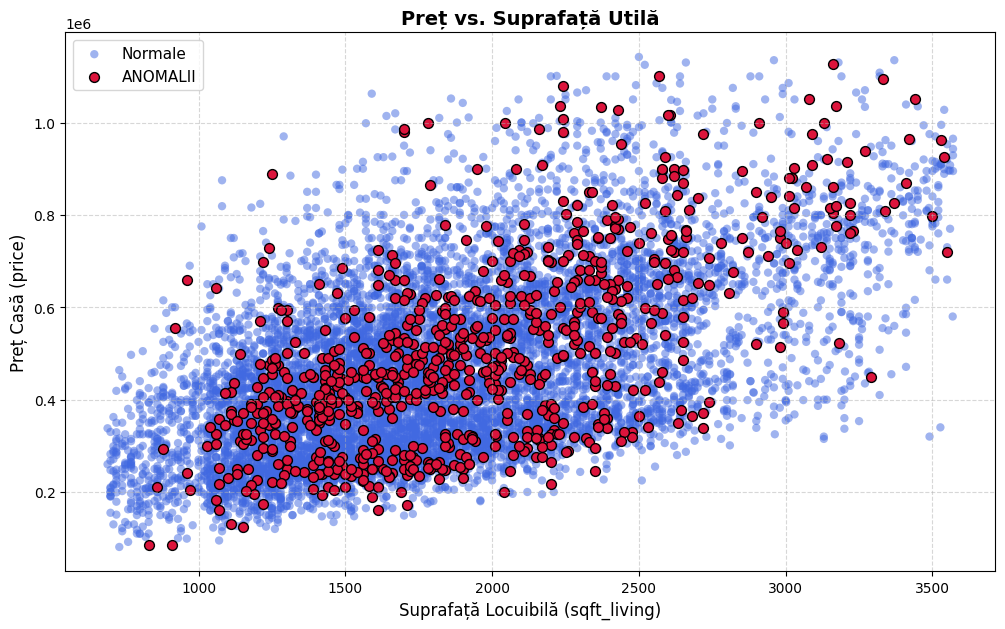

In [12]:
# Configurăm dimensiunea graficului
plt.figure(figsize=(12, 7))


plt.scatter(data_clean['sqft_living'], data_clean['price'], c='royalblue', 
            alpha=0.5, label='Normale', edgecolors='none')


plt.scatter(df_anomalii['sqft_living'], df_anomalii['price'], 
            c='crimson', s=50, label='ANOMALII', edgecolors='black')


plt.title('Preț vs. Suprafață Utilă', fontsize=14, fontweight='bold')
plt.xlabel('Suprafață Locuibilă (sqft_living)', fontsize=12)
plt.ylabel('Preț Casă (price)', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()